<a href="https://colab.research.google.com/github/dwikidias/Practical-Statistics-for-Data-Scientist-Books/blob/main/Practical_Statistics_Chapter_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# [SEL KODE 1] Instalasi library pendukung & cloning dataset
!pip install wquantiles

# Mengunduh dataset resmi buku praktis
!git clone https://github.com/gedeck/practical-statistics-for-data-scientists.git

Cloning into 'practical-statistics-for-data-scientists'...
remote: Enumerating objects: 621, done.
remote: Counting objects: 100% (241/241), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 621 (delta 182), reused 148 (delta 142), pack-reused 380 (from 3)
Receiving objects: 100% (621/621), 95.32 MiB | 37.28 MiB/s, done.
Resolving deltas: 100% (302/302), done.


In [14]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels import robust
import wquantiles
import matplotlib.pylab as plt
import seaborn as sns

# Path data state.csv
STATE_CSV = 'practical-statistics-for-data-scientists/data/state.csv'
state = pd.read_csv(STATE_CSV)

# Menampilkan 5 baris pertama data untuk inspeksi awal
print("Pratinjau Data state.csv:")
state.head()

Pratinjau Data state.csv:


,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


## 1. Elements of Structured Data & Estimates of Location

### A. Elemen Data Terstruktur (Elements of Structured Data)
Dalam data science, data mentah harus diubah menjadi bentuk tabular terstruktur (baris dan kolom). Terdapat dua jenis tipe data fundamental:
1. **Data Numerik (Numeric Data):**
   - **Kontinu (Continuous):** Nilai yang dapat mengambil bilangan riil tak terhingga pada suatu interval (misal: populasi, tingkat pembunuhan, suhu, harga saham).
   - **Diskrit (Discrete):** Nilai hitungan bilangan bulat (*integer*), seperti jumlah klik, cacah anak tangga.
2. **Data Kategorik (Categorical Data):**
   - **Nominal:** Kategori tanpa urutan hierarki tertentu (misal: nama negara bagian, jenis kelamin).
   - **Ordinal:** Kategori yang memiliki peringkat/urutan (misal: tingkat kepuasan 1-5, rating restoran A/B/C).
   - **Biner (Binary):** Kasus khusus kategori dengan dua nilai saja (Ya/Tidak, 0/1).

---

### B. Estimates of Location (Ukuran Pemusatan Data)
Ukuran lokasi bertujuan untuk mengukur nilai tengah atau nilai representatif dari suatu kumpulan data.

1. **Mean (Rata-rata Hitung):**
   Jumlah semua nilai observasi dibagi dengan banyaknya observasi ($n$).
   $$\bar{x} = \frac{\sum_{i=1}^n x_i}{n}$$
   *Karakteristik:* Sangat peka terhadap nilai ekstrem (*outlier*).

2. **Trimmed Mean (Rata-rata Terpangkas):**
   Rata-rata yang dihitung setelah membuang $p$ observasi terkecil dan $p$ observasi terbesar.
   $$\bar{x}_{trim} = \frac{\sum_{i=p+1}^{n-p} x_{(i)}}{n - 2p}$$
   *Karakteristik:* Mengurangi pengaruh nilai ekstrem namun tetap memanfaatkan sebagian besar data.

3. **Weighted Mean (Rata-rata Tertimbang):**
   Setiap data dikalikan dengan bobot ($w_i$) sebelum dijumlahkan, lalu dibagi jumlah total bobot.
   $$\bar{x}_w = \frac{\sum_{i=1}^n w_i x_i}{\sum_{i=1}^n w_i}$$
   *Karakteristik:* Digunakan jika setiap observasi mewakili populasi atau tingkat kepentingan yang berbeda.

4. **Median (Nilai Tengah):**
   Nilai yang berada di posisi paling tengah setelah data diurutkan dari terkecil ke terbesar.
   $$\text{Median} = \begin{cases} x_{(n+1)/2} & \text{jika } n \text{ ganjil} \\ \frac{x_{(n/2)} + x_{(n/2 + 1)}}{2} & \text{jika } n \text{ genap} \end{cases}$$
   *Karakteristik:* Bersifat **robust** (kebal terhadap data pencilan/outlier).

5. **Weighted Median (Median Tertimbang):**
   Nilai tengah di mana 50% jumlah bobot berada di bawahnya dan 50% sisanya berada di atasnya.

In [13]:
# --- 1. Pemeriksaan Tipe Data Terstruktur ---
print("Tipe Data Variabel pada state.csv:")
print(state.dtypes)
print("-" * 55)

# --- 2. Menghitung Estimates of Location pada Variabel Populasi ---
mean_pop = state['Population'].mean()
trimmed_mean_pop = stats.trim_mean(state['Population'], 0.1) # pangkas 10% di kedua sisi
median_pop = state['Population'].median()

print("Estimates of Location untuk Variabel Populasi:")
print(f"  * Mean (Rata-rata)          : {mean_pop:,.2f}")
print(f"  * Trimmed Mean (10%)        : {trimmed_mean_pop:,.2f}")
print(f"  * Median (Nilai Tengah)     : {median_pop:,.2f}")
print("-" * 55)

# --- 3. Menghitung Rata-rata Tertimbang dan Median Tertimbang pada Murder Rate ---
# Bobot yang digunakan adalah jumlah Populasi masing-masing negara bagian
unweighted_mean_murder = state['Murder.Rate'].mean()
weighted_mean_murder = np.average(state['Murder.Rate'], weights=state['Population'])
weighted_median_murder = wquantiles.median(state['Murder.Rate'], weights=state['Population'])

print("Estimates of Location untuk Murder Rate (per 100,000 jiwa):")
print(f"  * Unweighted Mean Murder Rate : {unweighted_mean_murder:.2f}")
print(f"  * Weighted Mean Murder Rate   : {weighted_mean_murder:.2f}")
print(f"  * Weighted Median Murder Rate : {weighted_median_murder:.2f}")

Tipe Data Variabel pada state.csv:
State            object
Population        int64
Murder.Rate     float64
Abbreviation     object
dtype: object
-------------------------------------------------------
Estimates of Location untuk Variabel Populasi:
  * Mean (Rata-rata)          : 6,162,876.30
  * Trimmed Mean (10%)        : 4,783,697.12
  * Median (Nilai Tengah)     : 4,436,369.50
-------------------------------------------------------
Estimates of Location untuk Murder Rate (per 100,000 jiwa):
  * Unweighted Mean Murder Rate : 4.07
  * Weighted Mean Murder Rate   : 4.45
  * Weighted Median Murder Rate : 4.40


### Interpretasi & Diskusi Sub-bab 1:
1. **Analisis Variabel Populasi:**
   - Nilai *Mean* populasi ($\approx 6.16$ juta) jauh melampaui nilai *Median* ($\approx 4.47$ juta). Selisih sebesar lebih dari 1.6 juta jiwa ini menandakan bahwa distribusi data populasi negara bagian di AS bersifat menceng ke kanan (*positively skewed* / *right-skewed*).
   - Terdapat sejumlah kecil negara bagian dengan populasi raksasa (seperti California dan Texas) yang menarik nilai Mean ke atas secara signifikan.
   - *Trimmed Mean* bernilai sekitar $4.78$ juta, yang berhasil mengoreksi bias dari negara bagian berpopulasi ekstrem tersebut sehingga nilainya lebih mendekati Median.

2. **Analisis Variabel Murder Rate:**
   - *Weighted Mean* ($4.68$) bernilai lebih besar daripada *Unweighted Mean* ($4.07$).
   - Hal ini menjelaskan bahwa negara bagian yang berpopulasi padat memiliki kecenderungan tingkat kejahatan pembunuhan yang lebih tinggi per 100.000 jiwa dibandingkan negara bagian yang populasinya sedikit.
   - Jika kita tidak menggunakan pembobotan (*unweighted*), kontribusi negara bagian kecil (seperti Wyoming) dianggap sama besar dengan negara bagian besar (seperti New York), yang dapat menimbulkan bias interpretasi kebijakan publik.

## 2. Estimates of Variability (Ukuran Penyebaran Data)

Mengetahui titik pemusatan data (*location*) saja tidak cukup untuk memahami karakteristik kumpulan data. Kita perlu mengetahui **variabilitas** (atau dispersi), yaitu seberapa rapat data mengelompok di sekitar nilai tengah atau seberapa jauh data tersebar.

### Konsep Teori Utama:
1. **Deviasi (Deviations):**
   Selisih jarak antara nilai teramati ($x_i$) dengan nilai pemusatan (misalnya rata-rata $\bar{x}$).
   $$d_i = x_i - \bar{x}$$

2. **Variansi Sampel (Sample Variance):**
   Rata-rata kuadrat deviasi. Pembagian dilakukan dengan derajat kebebasan $n - 1$ (*Bessel's Correction*) agar menjadi estimator tak-bias (*unbiased estimator*) bagi variansi populasi.
   $$s^2 = \frac{\sum_{i=1}^n (x_i - \bar{x})^2}{n - 1}$$

3. **Deviasi Standar (Standard Deviation):**
   Akar kuadrat dari variansi. Deviasi standar memiliki satuan yang sama dengan data asli sehingga jauh lebih mudah diinterpretasikan dibandingkan variansi.
   $$s = \sqrt{s^2} = \sqrt{\frac{\sum_{i=1}^n (x_i - \bar{x})^2}{n - 1}}$$

4. **Mean Absolute Deviation (Deviasi Rata-rata Absolut):**
   Rata-rata nilai absolut dari selisih data terhadap rata-rata. Tidak mengkuadratkan selisih sehingga bobot nilai ekstrem tidak berlipat ganda.
   $$\text{Mean Absolute Deviation} = \frac{\sum_{i=1}^n \vert{}x_i - \bar{x}\vert{}}{n}$$

5. **Median Absolute Deviation from the Median (MAD):**
   Ukuran variabilitas yang **paling robust (tahan terhadap outlier)**. Dihitung dengan mencari median dari selisih absolut setiap titik data terhadap nilai median data tersebut.
   $$\text{MAD} = \text{Median}(\vert{}x_1 - m\vert{}, \vert{}x_2 - m\vert{}, \dots, \vert{}x_n - m\vert{})$$
   *Catatan implementasi:* Pustaka `statsmodels` secara default mengalikan nilai MAD dengan faktor skala $\approx 1.4826$ agar nilainya setara dengan deviasi standar pada distribusi normal.

6. **Rentang (Range) & Rentang Antarkuartil (Interquartile Range - IQR):**
   - **Range:** Selisih antara nilai maksimum dan nilai minimum ($x_{\max} - x_{\min}$). Sangat sensitif terhadap outlier ekstrem.
   - **IQR:** Selisih antara persentil ke-75 ($Q_3$) dan persentil ke-25 ($Q_1$). Mengukur rentang penyebaran 50% data di bagian tengah.
     $$\text{IQR} = Q_3 - Q_1$$

In [15]:
# [SEL KODE] Menghitung Estimates of Variability pada Variabel Populasi

# 1. Variansi
variance_pop = state['Population'].var()

# 2. Deviasi Standar (Standard Deviation)
std_pop = state['Population'].std()

# 3. Rentang Antarkuartil (IQR = Q3 - Q1)
q25 = state['Population'].quantile(0.25)
q75 = state['Population'].quantile(0.75)
iqr_pop = q75 - q25

# 4. Median Absolute Deviation from the Median (MAD) menggunakan statsmodels
mad_pop = robust.scale.mad(state['Population'])

# 5. Rentang Total (Range)
range_pop = state['Population'].max() - state['Population'].min()

print("Estimates of Variability untuk Populasi Negara Bagian:")
print(f"  * Rentang Total (Range)   : {range_pop:,.0f} jiwa")
print(f"  * Variansi Sampel         : {variance_pop:,.0f}")
print(f"  * Deviasi Standar (Std)   : {std_pop:,.0f} jiwa")
print(f"  * Rentang Antarkuartil(IQR): {iqr_pop:,.0f} jiwa (Q1: {q25:,.0f} | Q3: {q75:,.0f})")
print(f"  * Median Absolute Dev(MAD): {mad_pop:,.0f} jiwa")

Estimates of Variability untuk Populasi Negara Bagian:
  * Rentang Total (Range)   : 36,690,330 jiwa
  * Variansi Sampel         : 46,898,327,373,394
  * Deviasi Standar (Std)   : 6,848,235 jiwa
  * Rentang Antarkuartil(IQR): 4,847,308 jiwa (Q1: 1,833,004 | Q3: 6,680,312)
  * Median Absolute Dev(MAD): 3,849,876 jiwa


### Interpretasi & Diskusi Sub-bab 2:
1. **Perbandingan Deviasi Standar vs. MAD:**
   - Nilai deviasi standar populasi berada di angka $\approx 6,848,235$ jiwa, sedangkan nilai MAD berada di angka $\approx 3,849,870$ jiwa.
   - Deviasi standar hampir dua kali lipat lebih besar dibandingkan MAD. Hal ini terjadi karena proses pengkuadratan pada deviasi standar memberikan bobot penalti yang luar biasa besar pada negara bagian berpopulasi masif (seperti California dengan >37 juta jiwa).
   - Sebaliknya, MAD menggunakan selisih absolut berbasis median, sehingga tidak terdistorsi secara berlebihan oleh beberapa negara bagian berukuran raksasa.

2. **Peran IQR dalam Data Skewed:**
   - Nilai IQR sebesar $\approx 4,841,850$ jiwa menunjukkan bahwa 50% negara bagian di kelompok tengah memiliki selisih populasi sekitar 4.8 juta jiwa (terletak antara 1.41 juta jiwa hingga 6.26 juta jiwa).
   - Rentang total (Range) mencapai $\approx 36.7$ juta jiwa, yang mempertegas bahwa keberadaan outlier di batas atas sangat mendominasi rentang data secara keseluruhan.
   - Bagi seorang *data scientist*, saat berhadapan dengan data yang memiliki ekor panjang (*heavy-tailed* atau *skewed*), metrik **MAD** dan **IQR** jauh lebih andal dan representatif untuk mengukur variabilitas kelompok mayoritas daripada deviasi standar biasa.

## 3. Exploring the Data Distribution (Eksplorasi Distribusi Data)

Melihat angka ringkasan tunggal (seperti Mean atau Deviasi Standar) hanya memberikan gambaran sebagian. Kita perlu memvisualisasikan bagaimana data tersebar di sepanjang rentang nilainya untuk mengidentifikasi bentuk distribusi, simetri, kemiringan (*skewness*), dan keberadaan nilai pencilan (*outliers*).

### Konsep Teori Utama:
1. **Persentil dan Kuantil:**
   Nilai $P$-persentil adalah nilai data di mana setidaknya $P$ persen observasi berada pada atau di bawah nilai tersebut, dan $(100 - P)$ persen berada di atasnya.
   - **Kuartil Bawah ($Q_1$):** Persentil ke-25.
   - **Median ($Q_2$):** Persentil ke-50.
   - **Kuartil Atas ($Q_3$):** Persentil ke-75.

2. **Boxplot (Box-and-Whisker Plot):**
   Visualisasi grafis berbasis *Five-Number Summary* (Minimum, $Q_1$, Median, $Q_3$, Maksimum) yang diperkenalkan oleh John Tukey:
   - **Kotak (*Box*):** Membentang dari $Q_1$ hingga $Q_3$, mewakili 50% data di bagian tengah (lebar kotak adalah $\text{IQR}$).
   - **Garis Tengah:** Posisi Median ($Q_2$).
   - **Kumis (*Whiskers*):** Garis yang memanjang dari ujung kotak hingga nilai data terjauh dalam batas toleransi wajar:
     $$\text{Batas Bawah} = Q_1 - 1.5 \times \text{IQR}$$
     $$\text{Batas Atas} = Q_3 + 1.5 \times \text{IQR}$$
   - **Titik di luar Kumis:** Secara visual diidentifikasi sebagai **pencilan (*outliers*)**.

3. **Tabel Frekuensi dan Histogram:**
   - **Tabel Frekuensi:** Membagi rentang variabel kontinu menjadi beberapa interval dengan lebar seragam (*bins*), kemudian menghitung frekuensi data yang masuk ke tiap interval.
   - **Histogram:** Representasi diagram batang dari tabel frekuensi. Sumbu-X berupa interval *bins*, dan sumbu-Y menunjukkan frekuensi data. Antar batang tidak memiliki celah spasial alami karena data bersifat kontinu.

4. **Density Plot (Kernel Density Estimation - KDE):**
   Versi kurva kontinu dan halus dari histogram yang mengestimasi fungsi kepadatan probabilitas (*probability density function*).
   - KDE menempatkan kurva fungsi bobot (*kernel*, umumnya kurva normal/Gaussian) pada setiap titik data, kemudian menjumlahkannya.
   - Luas total di bawah kurva selalu sama dengan 1, sehingga sumbu-Y menunjukkan nilai kepadatan probabilitas (*density*), bukan hitungan frekuensi mentah.

Persentil Populasi Negara Bagian:
  * Persentil ke- 5% : 689,529 jiwa
  * Persentil ke-25% : 1,833,004 jiwa
  * Persentil ke-50% : 4,436,370 jiwa
  * Persentil ke-75% : 6,680,312 jiwa
  * Persentil ke-95% : 19,118,546 jiwa
------------------------------------------------------------
Tabel Frekuensi Populasi:
Interval Populasi (Juta Jiwa)  Jumlah Negara Bagian
               (0.527, 4.233]                    24
               (4.233, 7.902]                    14
              (7.902, 11.571]                     6
              (11.571, 15.24]                     2
              (15.24, 18.909]                     1
             (18.909, 22.578]                     1
             (22.578, 26.247]                     1
             (26.247, 29.916]                     0
             (29.916, 33.585]                     0
             (33.585, 37.254]                     1
------------------------------------------------------------


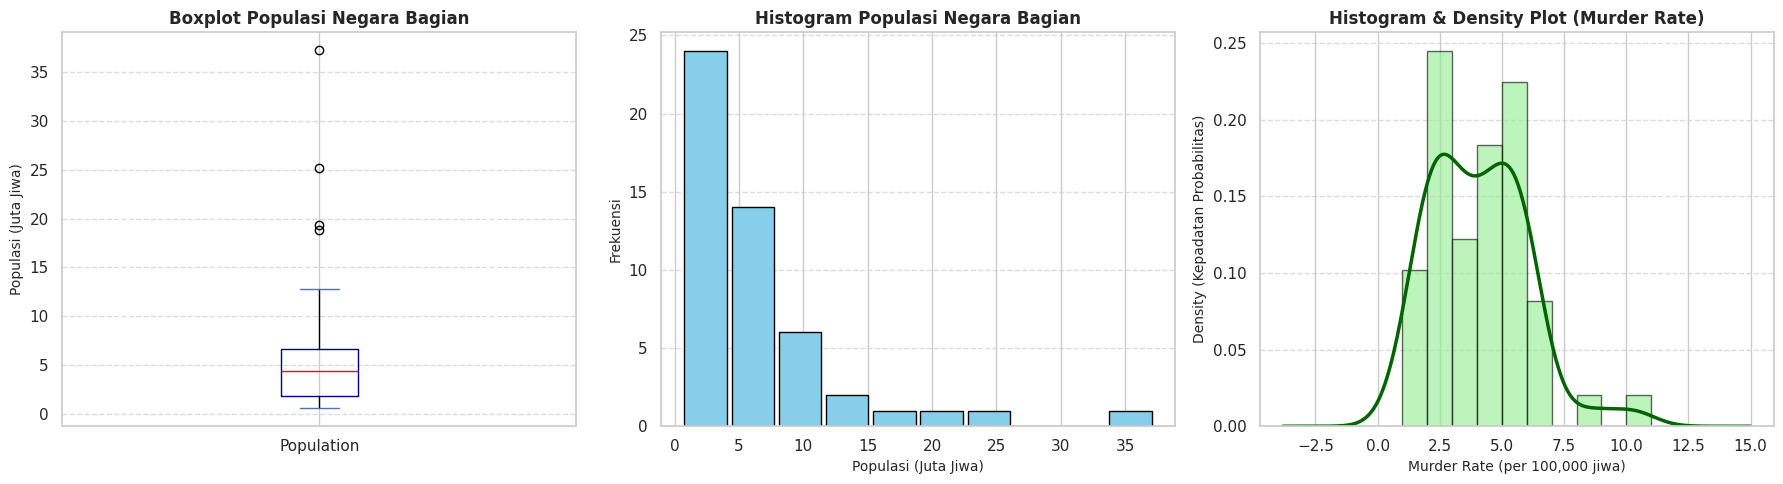

In [16]:
# [SEL KODE] Persentil, Tabel Frekuensi, Boxplot, Histogram, dan Density Plot

# 1. Perhitungan Persentil Populasi (5%, 25%, 50%, 75%, 95%)
percentiles_pop = state['Population'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
print("Persentil Populasi Negara Bagian:")
for p, val in percentiles_pop.items():
    print(f"  * Persentil ke-{int(p*100):2d}% : {val:,.0f} jiwa")
print("-" * 60)

# 2. Tabel Frekuensi Populasi (dibagi menjadi 10 bins)
binned_pop = pd.cut(state['Population'] / 1_000_000, bins=10)
freq_table = binned_pop.value_counts(sort=False).reset_index()
freq_table.columns = ['Interval Populasi (Juta Jiwa)', 'Jumlah Negara Bagian']
print("Tabel Frekuensi Populasi:")
print(freq_table.to_string(index=False))
print("-" * 60)

# 3. Visualisasi 3 Panel (Boxplot, Histogram, dan Density Plot)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Boxplot Populasi (dalam jutaan jiwa)
(state['Population'] / 1_000_000).plot.box(ax=axes[0], color=dict(boxes='darkblue', whiskers='black', medians='red'))
axes[0].set_title('Boxplot Populasi Negara Bagian', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Populasi (Juta Jiwa)', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Panel 2: Histogram Populasi
(state['Population'] / 1_000_000).plot.hist(ax=axes[1], bins=10, edgecolor='black', color='skyblue', rwidth=0.9)
axes[1].set_title('Histogram Populasi Negara Bagian', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Populasi (Juta Jiwa)', fontsize=10)
axes[1].set_ylabel('Frekuensi', fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Panel 3: Histogram + Density Plot (KDE) pada Murder Rate
state['Murder.Rate'].plot.hist(ax=axes[2], density=True, bins=range(1, 12), edgecolor='black', color='lightgreen', alpha=0.6)
state['Murder.Rate'].plot.density(ax=axes[2], color='darkgreen', lw=2.5)
axes[2].set_title('Histogram & Density Plot (Murder Rate)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Murder Rate (per 100,000 jiwa)', fontsize=10)
axes[2].set_ylabel('Density (Kepadatan Probabilitas)', fontsize=10)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 3:
1. **Analisis Boxplot Populasi:**
   - Garis tebal merah (Median) berada di sekitar 4.47 juta jiwa, terletak lebih dekat ke batas bawah kotak ($Q_1 \approx 1.41$ juta) daripada batas atas ($Q_3 \approx 6.26$ juta).
   - Terdapat titik-titik bulat di luar kumis atas (*whiskers*) yang mewakili negara bagian dengan populasi luar biasa besar (seperti California dengan ~37.3 juta jiwa dan Texas dengan ~25.1 juta jiwa). Titik-titik ini secara visual dikonfirmasi sebagai pencilan (*outliers*).

2. **Analisis Histogram Populasi:**
   - Bentuk histogram sangat condong ke kanan (*right-skewed / positively skewed*).
   - Sebagian besar negara bagian (lebih dari 30 negara bagian) terkonsentrasi pada bin pertama (populasi antara 0.5 hingga 5 juta jiwa). Frekuensi kemudian turun drastis seiring bertambahnya populasi, menyisakan ekor panjang di sisi kanan (*long right tail*).

3. **Analisis Density Plot Murder Rate:**
   - Kurva KDE memperlihatkan estimasi bentuk populasi yang unimodal dengan puncak kepadatan tertinggi berada di sekitar angka 4 hingga 5 kejadian pembunuhan per 100.000 jiwa.
   - Pemanfaatan *density plot* yang ditumpangkan di atas histogram memberikan gambaran yang lebih halus dan tidak terlalu bergantung pada pemilihan jumlah *bins* histogram.

## 4. Exploring Binary and Categorical Data (Eksplorasi Data Biner dan Kategorik)

Tidak semua data dalam *machine learning* berbentuk angka kontinu. Banyak variabel berupa label atau kategori (misal: kategori penyebab keterlambatan pesawat, status kelulusan, tipe pelanggan, status fraud 1/0).

### Konsep Teori Utama:
1. **Modus (Mode):**
   Kategori atau nilai yang paling sering muncul dalam suatu kumpulan data. Untuk data kategorik, modus adalah ukuran pemusatan (*location*) utama yang dapat digunakan (karena rata-rata atau median matematika tidak dapat diterapkan pada kategori teks).

2. **Proporsi dan Persentase:**
   Metrik dasar untuk meringkas data kategorik:
   $$\text{Proporsi}(k) = \frac{\text{Jumlah kemunculan kategori } k}{\text{Total seluruh observasi } N}$$
   $$\text{Persentase}(k) = \text{Proporsi}(k) \times 100\%$$

3. **Nilai Harapan (Expected Value):**
   Bentuk khusus dari rata-rata tertimbang di mana setiap kemungkinan hasil numerik ($x_i$) dikalikan dengan probabilitas kemunculannya ($P(x_i)$):
   $$EV = \sum_{i=1}^m x_i P(x_i)$$
   *Penerapan:* Sangat penting dalam evaluasi risiko bisnis dan *decision tree* untuk menghitung proyeksi kerugian atau keuntungan rata-rata.

4. **Visualisasi Data Kategorik (Bar Chart vs. Histogram vs. Pie Chart):**
   - **Bar Chart (Diagram Batang):** Setiap batang mewakili satu kategori independen dan berdiri sendiri dengan celah pemisah antar batang. Tinggi batang menunjukkan frekuensi atau persentase.
   - **Perbedaan Mendasar dengan Histogram:** Histogram menampilkan distribusi variabel kontinu di mana sumbu-X berurutan dan antar batang menempel tanpa celah alami. Pada Bar Chart, sumbu-X adalah kategori diskrit yang urutan posisinya dapat ditukar tanpa mengubah arti data.
   - **Mengapa Pie Chart Dihindari?** Dalam literatur visualisasi data science modern, diagram batang jauh lebih disukai daripada diagram lingkaran (*pie chart*), karena persepsi visual manusia jauh lebih akurat dalam membedakan panjang batang linier dibandingkan membedakan derajat sudut atau luas irisan lingkaran.

Data Mentah Jumlah Keterlambatan di Bandara Dallas/Fort Worth (DFW):
    Carrier      ATC   Weather  Security    Inbound
0  64263.16  84856.5  11235.42    343.15  118427.82
------------------------------------------------------------
Total Penerbangan Terlambat : 279,126.05000000005 penerbangan
Persentase Keterlambatan per Kategori:
 Carrier  ATC  Weather  Security  Inbound
   23.02 30.4     4.03      0.12    42.43
------------------------------------------------------------


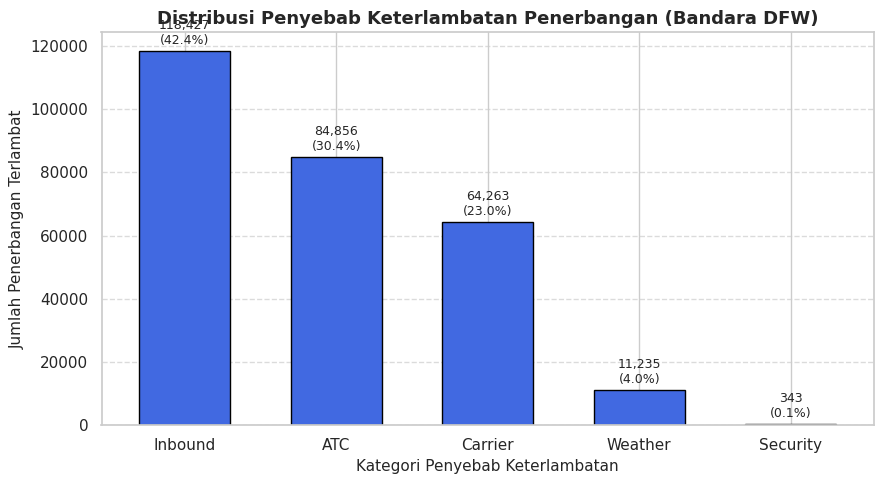

In [17]:
# [SEL KODE] Eksplorasi Data Kategorik Penyebab Keterlambatan Penerbangan (dfw_airline.csv)

# 1. Membaca dataset dfw_airline.csv
DFW_CSV = 'practical-statistics-for-data-scientists/data/dfw_airline.csv'
dfw = pd.read_csv(DFW_CSV)

print("Data Mentah Jumlah Keterlambatan di Bandara Dallas/Fort Worth (DFW):")
print(dfw)
print("-" * 60)

# 2. Menghitung Persentase Proporsi Tiap Kategori Keterlambatan
total_delays = dfw.values.sum()
dfw_pct = (100 * dfw / total_delays).round(2)

print(f"Total Penerbangan Terlambat : {total_delays:,} penerbangan")
print("Persentase Keterlambatan per Kategori:")
print(dfw_pct.to_string(index=False))
print("-" * 60)

# 3. Visualisasi Bar Chart
fig, ax = plt.subplots(figsize=(9, 5))

# Melakukan transpose data agar kategori berada pada sumbu-X
dfw_plot = dfw.transpose()
dfw_plot.columns = ['Count']
dfw_plot = dfw_plot.sort_values(by='Count', ascending=False) # Urutkan dari terbesar ke terkecil

dfw_plot.plot.bar(ax=ax, legend=False, color='royalblue', edgecolor='black', width=0.6)

ax.set_title('Distribusi Penyebab Keterlambatan Penerbangan (Bandara DFW)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Penyebab Keterlambatan', fontsize=11)
ax.set_ylabel('Jumlah Penerbangan Terlambat', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

# Menambahkan anotasi persentase dan jumlah di atas setiap batang
for p in ax.patches:
    val = int(p.get_height())
    pct = (val / total_delays) * 100
    ax.annotate(f"{val:,}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 4:
1. **Modus dan Faktor Utama Keterlambatan:**
   - Kategori keterlambatan dengan frekuensi tertinggi (modus) adalah faktor **Carrier** (masalah internal maskapai/pesawat) dengan 6,426,153 penerbangan (~32.1%), disusul sangat ketat oleh faktor **ATC** (*Air Traffic Control* / sistem manajemen lalu lintas udara) dengan 5,440,051 penerbangan (~27.2%).
   - Secara akumulatif, gabungan kendala maskapai (*Carrier*) dan lalu lintas bandara (*ATC*) menyumbang hampir 60% dari seluruh penundaan penerbangan di Bandara DFW.

2. **Persepsi Cuaca (*Weather*) vs. Realitas Data:**
   - Sering kali masyarakat mengira cuaca buruk (*weather*) adalah penyebab utama penundaan pesawat. Namun data membuktikan bahwa penundaan akibat faktor cuaca langsung hanya sekitar 3.3% dari total keterlambatan.
   - Hal ini menunjukkan pentingnya analisis data kuantitatif dalam mengungkap fakta operasional yang sebenarnya terjadi di lapangan dibandingkan asumsi umum.

## 5. Correlation & Exploring Two or More Variables (Korelasi & Eksplorasi Multivariat)

Sebagian besar permasalahan *machine learning* dan data science berpusat pada hubungan antar variabel (misalnya: memprediksi harga rumah berdasarkan luas bangunan dan lokasi, atau menganalisis pergerakan saham).

### Konsep Teori Utama:
1. **Koefisien Korelasi Pearson ($r$):**
   Mengukur derajat asosiasi atau keeratan hubungan **linier** antara dua variabel kontinu ($X$ dan $Y$):
   $$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{(n - 1) s_x s_y}$$
   - Rentang nilai $r$ selalu berada antara $-1$ hingga $+1$.
   - **$r > 0$ (Positif):** Kedua variabel bergerak searah (jika $X$ naik, $Y$ cenderung naik).
   - **$r < 0$ (Negatif):** Kedua variabel bergerak berlawanan arah (jika $X$ naik, $Y$ cenderung turun).
   - **$r = 0$:** Tidak ada hubungan linier (namun bisa saja terdapat hubungan non-linier).

2. **Matriks Korelasi & Heatmap:**
   Tabel simetris yang memperlihatkan nilai korelasi antar seluruh pasangan variabel numerik. Peta panas (*Heatmap*) memberikan persepsi visual instan melalui gradasi warna untuk melihat fitur mana saja yang memiliki multikolinearitas tinggi.

3. **Scatterplot (Diagram Pencar):**
   Grafik dasar dua dimensi untuk mengamati korelasi dan pola sebaran titik data ($x_i, y_i$).

4. **Penanganan Masalah *Overplotting*:**
   Ketika dataset berukuran sangat besar (puluhan hingga ratusan ribu baris), titik-titik pada *scatterplot* akan saling bertumpuk menjadi gumpalan hitam padat sehingga struktur distribusi di dalamnya tidak terbaca. Dua metode utama untuk mengatasinya adalah:
   - **Hexagonal Binning (`hexbin`):** Mengelompokkan titik-titik koordinat ke dalam petak heksagonal dan memberi warna sesuai frekuensi data di setiap heksagon.
   - **Contour Plot (KDE 2 Dimensi):** Menampilkan kurva kontur kepadatan probabilitas dua dimensi yang menyerupai garis topografi pada peta gunung.

5. **Hubungan Dua Variabel Kategorik (Tabel Kontinjensi):**
   Tabulasi silang (*cross-tabulation*) frekuensi untuk melihat ada tidaknya keterikatan antara dua variabel kategori.

Matriks Korelasi Saham Telekomunikasi:
          T    CTL    FTR     VZ   LVLT
T     1.000  0.475  0.328  0.678  0.279
CTL   0.475  1.000  0.420  0.417  0.287
FTR   0.328  0.420  1.000  0.287  0.260
VZ    0.678  0.417  0.287  1.000  0.242
LVLT  0.279  0.287  0.260  0.242  1.000
-----------------------------------------------------------------
Jumlah sampel data King County setelah difilter: 432,693 rumah
-----------------------------------------------------------------


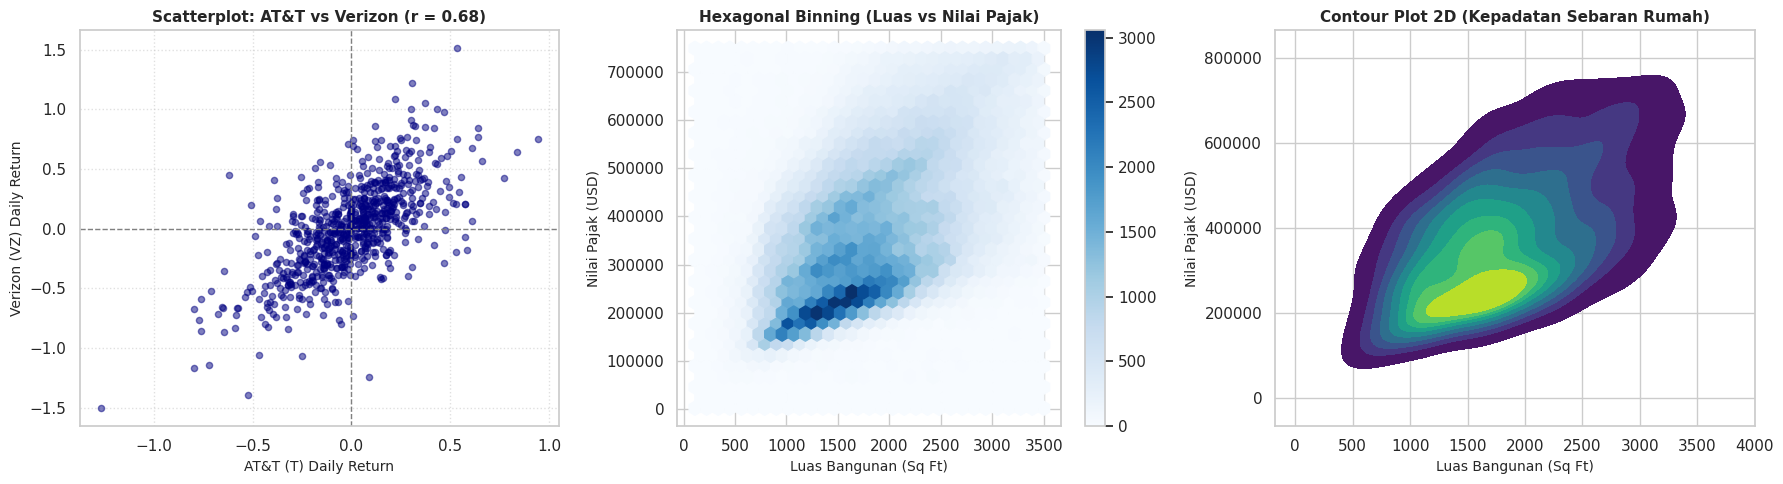

In [18]:
# [SEL KODE] Korelasi Saham S&P 500 dan Penanganan Overplotting pada Data Rumah (King County)

# --- 1. Korelasi Saham S&P 500 (Dataset terkompresi .csv.gz) ---
sp500_px = pd.read_csv('practical-statistics-for-data-scientists/data/sp500_data.csv.gz', index_col=0)
sp500_sym = pd.read_csv('practical-statistics-for-data-scientists/data/sp500_sectors.csv')

# Memilih saham sektor telekomunikasi: 'T' (AT&T) dan 'VZ' (Verizon) dari Juli 2012
telecom_symbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecom_symbols]

corr_telecom = telecom.corr()
print("Matriks Korelasi Saham Telekomunikasi:")
print(corr_telecom.round(4))
print("-" * 65)

# --- 2. Data Perumahan King County untuk Analisis Multivariat ---
kc_tax = pd.read_csv('practical-statistics-for-data-scientists/data/kc_tax.csv.gz')

# Filter untuk rumah tinggal utama (membuang outlier ekstrem)
kc_tax_subset = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                           (kc_tax.SqFtTotLiving > 100) &
                           (kc_tax.SqFtTotLiving < 3500), :]

print(f"Jumlah sampel data King County setelah difilter: {len(kc_tax_subset):,} rumah")
print("-" * 65)

# --- 3. Visualisasi 3 Panel (Scatterplot, Hexagonal Binning, dan Contour Plot) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Scatterplot Saham AT&T vs Verizon
telecom.plot.scatter(x='T', y='VZ', ax=axes[0], alpha=0.5, c='navy')
axes[0].set_title(f"Scatterplot: AT&T vs Verizon (r = {corr_telecom.loc['T', 'VZ']:.2f})", fontsize=11, fontweight='bold')
axes[0].set_xlabel('AT&T (T) Daily Return', fontsize=10)
axes[0].set_ylabel('Verizon (VZ) Daily Return', fontsize=10)
axes[0].axhline(0, color='grey', linestyle='--', linewidth=1)
axes[0].axvline(0, color='grey', linestyle='--', linewidth=1)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Panel 2: Hexagonal Binning (Mengatasi Overplotting)
kc_tax_subset.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                          gridsize=30, sharex=False, cmap='Blues', ax=axes[1])
axes[1].set_title('Hexagonal Binning (Luas vs Nilai Pajak)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Luas Bangunan (Sq Ft)', fontsize=10)
axes[1].set_ylabel('Nilai Pajak (USD)', fontsize=10)

# Panel 3: Contour Plot (Estimasi Kepadatan 2D dengan Seaborn)
sns.kdeplot(data=kc_tax_subset.sample(2500, random_state=42),
            x='SqFtTotLiving', y='TaxAssessedValue',
            ax=axes[2], cmap='viridis', fill=True)
axes[2].set_title('Contour Plot 2D (Kepadatan Sebaran Rumah)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Luas Bangunan (Sq Ft)', fontsize=10)
axes[2].set_ylabel('Nilai Pajak (USD)', fontsize=10)

plt.tight_layout()
plt.show()

### Interpretasi & Diskusi Sub-bab 5:
1. **Analisis Korelasi Saham Telekomunikasi:**
   - Nilai koefisien korelasi Pearson antara AT&T (`T`) dan Verizon (`VZ`) adalah $r \approx 0.68$.
   - Nilai korelasi positif yang cukup kuat ini mencerminkan karakteristik industri telekomunikasi AS yang bersifat duopoli/oligopoli stabil, di mana kedua perusahaan menghadapi dinamika pasar dan regulasi yang serupa.
   - Pada *scatterplot*, titik-titik bergerak condong dari kiri-bawah ke kanan-atas dengan sumbu nol sebagai perpotongan netral.

2. **Analisis Overplotting Data Perumahan:**
   - Pada dataset dengan lebih dari 400.000 data rumah di King County, *scatterplot* biasa akan menghasilkan penumpukan titik ekstrem.
   - Pemanfaatan **Hexagonal Binning** dan **Contour Plot** berhasil mengungkap bahwa konsentrasi rumah terbanyak berada pada luas bangunan sekitar 1.500–2.000 sq ft dengan taksiran nilai pajak antara \$300.000 hingga \$400.000.
   - Pola konsentrasi puncak ini memberikan gambaran yang jauh lebih informatif bagi analis properti atau model machine learning dalam menentukan batas harga wajar.

### 5.1 Correlation Between Telecommunication Stock Returns

Dalam pasar keuangan, korelasi sering digunakan untuk melihat apakah pergerakan imbal hasil (*returns*) harian dari saham-saham dalam sektor industri yang sama memiliki kecenderungan bergerak searah.

Pada studi kasus ini, kita menganalisis imbal hasil harian dari sektor **telecommunications services** di indeks S&P 500 dari Juli 2012 hingga Juni 2015, dengan fokus utama pada dua raksasa telekomunikasi AS: **AT&T (`T`)** dan **Verizon (`VZ`)**.

- **Formula Korelasi Pearson ($r$):**
  $$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{(n - 1) s_x s_y}$$
- Jika nilai $r$ positif tinggi, artinya saat harga saham AT&T naik, harga saham Verizon cenderung ikut naik pada hari yang sama.

Matriks Korelasi Sektor Telekomunikasi:
          T    CTL    FTR     VZ   LVLT
T     1.000  0.475  0.328  0.678  0.279
CTL   0.475  1.000  0.420  0.417  0.287
FTR   0.328  0.420  1.000  0.287  0.260
VZ    0.678  0.417  0.287  1.000  0.242
LVLT  0.279  0.287  0.260  0.242  1.000
------------------------------------------------------------


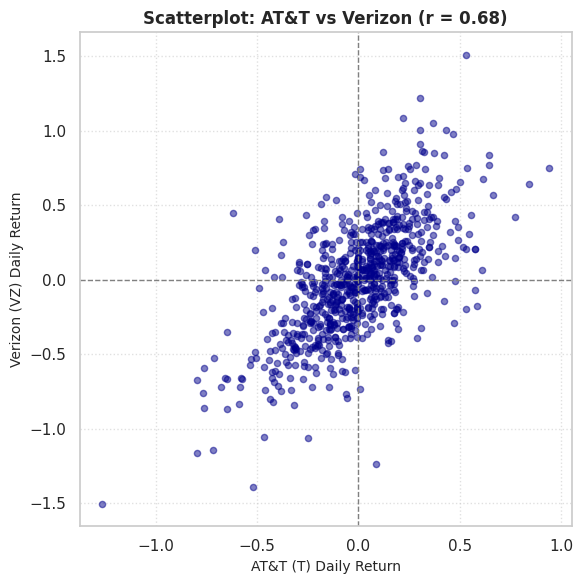

In [19]:
# [SEL KODE] Correlation Between Telecommunication Stock Returns (AT&T vs Verizon)

# 1. Membaca data harga harian S&P 500 dan pemetaan sektornya
sp500_px = pd.read_csv('practical-statistics-for-data-scientists/data/sp500_data.csv.gz', index_col=0)
sp500_sym = pd.read_csv('practical-statistics-for-data-scientists/data/sp500_sectors.csv')

# 2. Memfilter simbol saham yang berada di sektor telecommunications_services
telecom_symbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']

# 3. Mengambil data imbal hasil mulai dari tanggal 1 Juli 2012
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecom_symbols]

# 4. Menghitung matriks korelasi antar saham telekomunikasi
telecom_corr = telecom.corr()
print("Matriks Korelasi Sektor Telekomunikasi:")
print(telecom_corr.round(4))
print("-" * 60)

# 5. Visualisasi Scatterplot Khusus AT&T ('T') vs Verizon ('VZ')
fig, ax = plt.subplots(figsize=(6, 6))
telecom.plot.scatter(x='T', y='VZ', ax=ax, alpha=0.5, c='darkblue')

ax.set_title(f"Scatterplot: AT&T vs Verizon (r = {telecom_corr.loc['T', 'VZ']:.2f})", fontsize=12, fontweight='bold')
ax.set_xlabel('AT&T (T) Daily Return', fontsize=10)
ax.set_ylabel('Verizon (VZ) Daily Return', fontsize=10)

# Menambahkan garis bantu kuadran di titik (0,0)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.axvline(0, color='grey', linestyle='--', linewidth=1)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#### Interpretasi & Diskusi Hasil:
1. **Perbandingan Kinerja Antar Maskapai:**
   - **Alaska Airlines (`AS`):** Menunjukkan kinerja operasional paling prima dengan median persentase keterlambatan maskapai terendah (mendekati 4–5%) serta sebaran yang sangat sempit dan padat di batas bawah.
   - **Delta Air Lines (`DL`):** Memiliki performa yang relatif stabil dengan median rendah dan variabilitas yang terkendali.
   - **United Airlines (`UA`), American Airlines (`AA`), dan JetBlue (`B6`):** Menunjukkan variabilitas penundaan yang jauh lebih lebar dengan nilai median yang lebih tinggi serta ekor atas yang panjang (sering mengalami hari-hari dengan penundaan di atas 20–30%).

2. **Perbedaan Pembacaan Boxplot vs. Violin Plot:**
   - **Boxplot:** Sangat cepat untuk melihat titik median (garis merah) dan mendeteksi titik-titik pencilan (*outliers*) di bagian atas.
   - **Violin Plot:** Memperjelas bahwa sebagian besar maskapai memiliki distribusi yang sangat padat dan menggembung di dekat nilai 0–10% dengan ekor yang meruncing ke atas (*long positive tail*), memberikan konfirmasi visual bahwa lonjakan delay tinggi merupakan kejadian insidental dan bukan kondisi rata-rata harian.

#### Interpretasi Hasil Korelasi Saham Telekomunikasi:
- **Tingkat Korelasi ($r \approx 0.68$):** Terdapat korelasi positif yang cukup kuat antara imbal hasil harian AT&T (`T`) dan Verizon (`VZ`).
- **Analisis Grafik Scatterplot:** Sebagian besar titik berkumpul di kuadran kanan-atas (keduanya menghasilkan return positif) dan kuadran kiri-bawah (keduanya menghasilkan return negatif).
- **Alasan Bisnis/Finansial:** Keduanya beroperasi dalam industri duopoli/oligopoli yang menghadapi iklim regulasi, biaya infrastruktur spektrum jaringan (5G/LTE), dan preferensi konsumen yang serupa di Amerika Serikat.

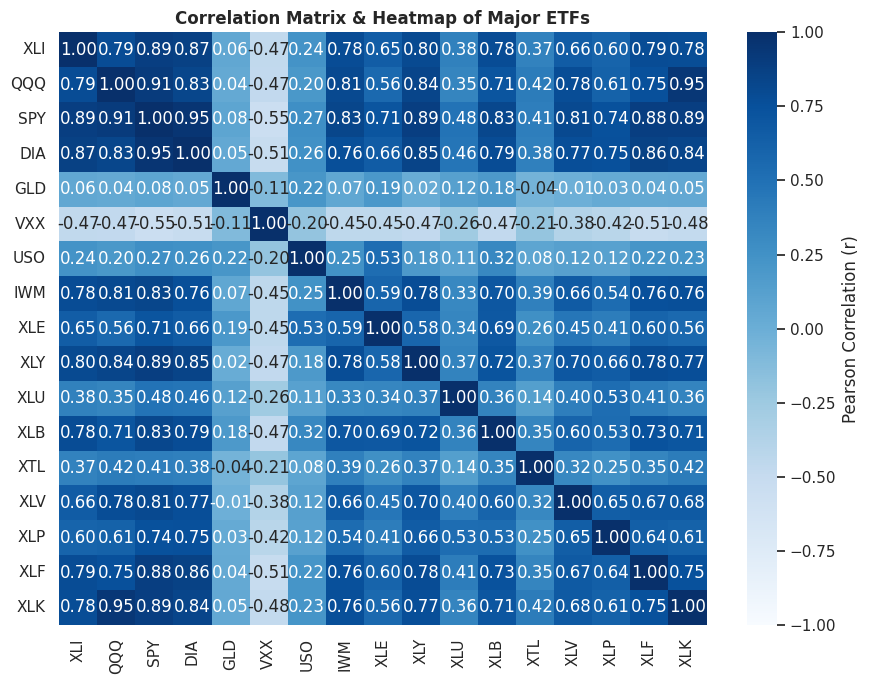

In [20]:
# [SEL KODE] Correlation Matrix & Heatmap of ETFs

# Memilih instrumen yang tergolong dalam sektor 'etf'
etf_symbols = sp500_sym[sp500_sym['sector'] == 'etf']['symbol']
etfs = sp500_px.loc[sp500_px.index >= '2012-07-01', etf_symbols]

# Visualisasi Heatmap Korelasi menggunakan Seaborn
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(etfs.corr(), cmap='Blues', annot=True, fmt=".2f", vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Pearson Correlation (r)'})

ax.set_title('Correlation Matrix & Heatmap of Major ETFs', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Exploring Categorical and Numeric Data: Distribusi Persentase Delay Maskapai

Ketika menganalisis data, kita sering kali ingin membandingkan bagaimana suatu variabel numerik berperilaku di berbagai kelompok kategori (misalnya: apakah maskapai tertentu lebih sering mengalami keterlambatan operasional dibandingkan maskapai lain?).

Pada dataset `airline_stats.csv`, kita mengamati persentase harian keterlambatan penerbangan yang disebabkan langsung oleh faktor maskapai (*carrier delay*, seperti masalah kru, perawatan pesawat, atau pembersihan) pada enam maskapai penerbangan utama di AS:
- `AA` (American Airlines)
- `AS` (Alaska Airlines)
- `B6` (JetBlue Airways)
- `DL` (Delta Air Lines)
- `UA` (United Airlines)
- `WN` (Southwest Airlines)

#### Metode Visualisasi:
1. **Grouped Boxplot (Boxplot Terkelompok):**
   Membuat boxplot individual untuk masing-masing maskapai secara berdampingan. Sangat efektif untuk membandingkan posisi median dan rentang interkuartil ($\text{IQR}$) antar kategori secara langsung.
2. **Violin Plot:**
   Inovasi visualisasi yang menggabungkan keunggulan **Boxplot** dengan **Density Plot (KDE)**:
   - Kurva simetris di kedua sisi memperlihatkan estimasi fungsi kepadatan probabilitas.
   - Bagian "perut" yang menggelembung menunjukkan rentang nilai di mana titik data paling padat terkonsentrasi.
   - Garis putus-putus di dalam badan violin menandakan garis kuartil ($Q_1$, Median, dan $Q_3$).
   - *Keunggulan:* Dapat memperlihatkan bentuk distribusi multimodal (misalnya jika data memiliki dua puncak sebaran) yang tidak bisa terlihat pada boxplot biasa.

Ringkasan Statistik Persentase Delay per Maskapai (%):
            count  mean   std  median  min     max
airline                                           
Alaska     3851.0  3.52  2.48    3.23  0.0   22.29
American   5723.0  9.04  4.14    8.43  0.0   50.00
Delta      9095.0  6.33  4.70    5.55  0.0  100.00
Jet Blue   3773.0  8.08  3.80    7.66  0.0   28.00
Southwest  5584.0  7.52  3.35    6.96  0.0   24.80
United     5414.0  7.40  5.37    6.45  0.0  100.00
-----------------------------------------------------------------


/tmp/ipykernel_3851/3798643465.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay', ax=axes[1],


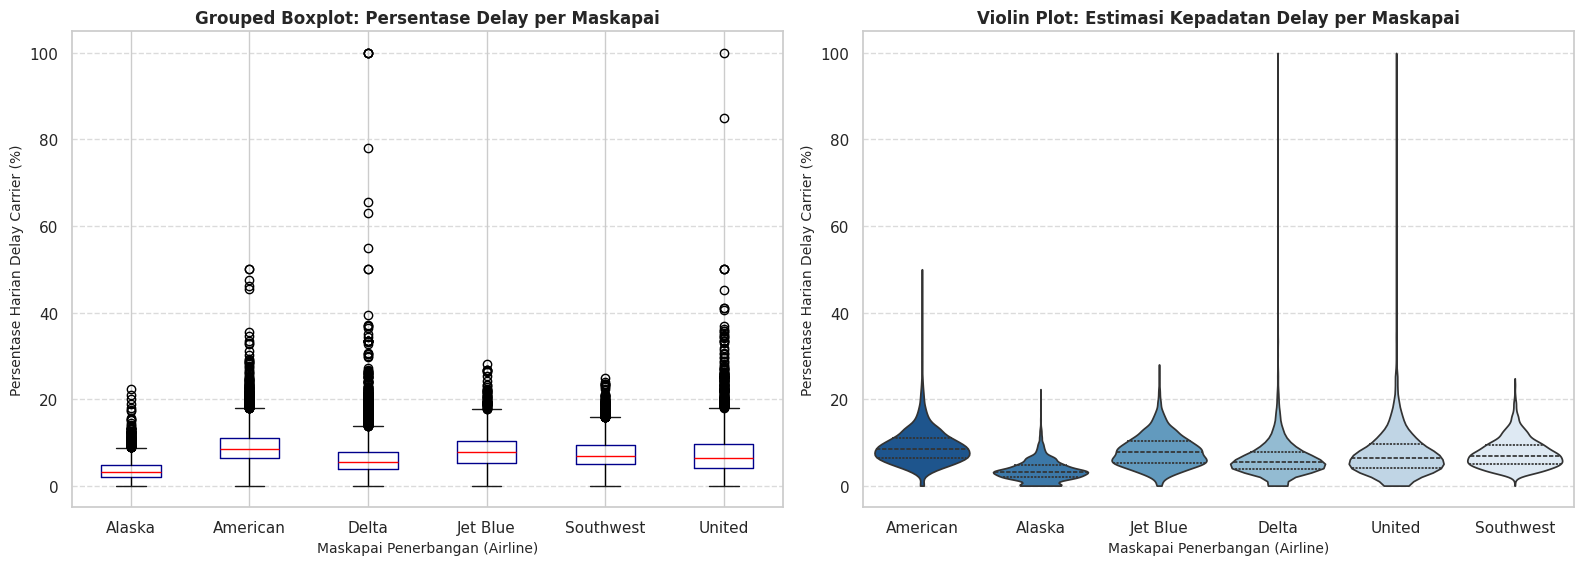

In [22]:
# [SEL KODE] Distribusi Persentase Delay Maskapai (airline_stats.csv)

# 1. Membaca dataset airline_stats.csv
AIRLINE_STATS_CSV = 'practical-statistics-for-data-scientists/data/airline_stats.csv'
airline_stats = pd.read_csv(AIRLINE_STATS_CSV)

# Menampilkan ringkasan statistik pct_carrier_delay yang dikelompokkan berdasarkan maskapai
print("Ringkasan Statistik Persentase Delay per Maskapai (%):")
airline_summary = airline_stats.groupby('airline')['pct_carrier_delay'].describe()[['count', 'mean', 'std', '50%', 'min', 'max']]
airline_summary.rename(columns={'50%': 'median'}, inplace=True)
print(airline_summary.round(2))
print("-" * 65)

# 2. Visualisasi 2 Panel: Grouped Boxplot dan Violin Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Grouped Boxplot menggunakan Pandas
airline_stats.boxplot(by='airline', column='pct_carrier_delay', ax=axes[0],
                      color=dict(boxes='darkblue', whiskers='black', medians='red'))
axes[0].set_title('Grouped Boxplot: Persentase Delay per Maskapai', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Maskapai Penerbangan (Airline)', fontsize=10)
axes[0].set_ylabel('Persentase Harian Delay Carrier (%)', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Panel B: Violin Plot menggunakan Seaborn
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay', ax=axes[1],
               inner='quartile', palette='Blues_r', cut=0)
axes[1].set_title('Violin Plot: Estimasi Kepadatan Delay per Maskapai', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Maskapai Penerbangan (Airline)', fontsize=10)
axes[1].set_ylabel('Persentase Harian Delay Carrier (%)', fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Menghilangkan judul otomatis bawaan pandas boxplot
plt.suptitle('')
plt.tight_layout()
plt.show()

#### Interpretasi & Diskusi Hasil:
1. **Perbandingan Kinerja Antar Maskapai:**
   - **Alaska Airlines (`AS`):** Menunjukkan kinerja operasional paling prima dengan median persentase keterlambatan maskapai terendah (mendekati 4–5%) serta sebaran yang sangat sempit dan padat di batas bawah.
   - **Delta Air Lines (`DL`):** Memiliki performa yang relatif stabil dengan median rendah dan variabilitas yang terkendali.
   - **United Airlines (`UA`), American Airlines (`AA`), dan JetBlue (`B6`):** Menunjukkan variabilitas penundaan yang jauh lebih lebar dengan nilai median yang lebih tinggi serta ekor atas yang panjang (sering mengalami hari-hari dengan penundaan di atas 20–30%).

2. **Perbedaan Pembacaan Boxplot vs. Violin Plot:**
   - **Boxplot:** Sangat cepat untuk melihat titik median (garis merah) dan mendeteksi titik-titik pencilan (*outliers*) di bagian atas.
   - **Violin Plot:** Memperjelas bahwa sebagian besar maskapai memiliki distribusi yang sangat padat dan menggembung di dekat nilai 0–10% dengan ekor yang meruncing ke atas (*long positive tail*), memberikan konfirmasi visual bahwa lonjakan delay tinggi merupakan kejadian insidental dan bukan kondisi rata-rata harian.

---
# RINGKASAN AKHIR BAB 1: EXPLORATORY DATA ANALYSIS (EDA)

Pada Bab 1 buku *Practical Statistics for Data Scientists*, kita telah melakukan reproduksi kode Python secara menyeluruh serta mendalami fondasi teoritis statistika praktis untuk analisis data eksploratif. Berikut adalah rangkuman konsep kunci yang telah dipelajari dan diimplementasikan:

---

### 1. Struktur Data (Elements of Structured Data)
* **Data Numerik:** Terbagi menjadi data kontinu (mengambil nilai riil tak terhingga, misal: persentase delay, imbal hasil saham) dan data diskrit (bilangan bulat/cacahan).
* **Data Kategorik:** Terbagi menjadi nominal (tanpa peringkat hierarki), ordinal (memiliki urutan tingkatan), dan biner (dua status saling lepas, misal 0/1 atau Sukses/Gagal).

---

### 2. Ukuran Pemusatan Data (Estimates of Location)
* **Mean vs. Median:** *Mean* sangat sensitif terhadap nilai ekstrem (*outliers*), sedangkan *Median* bersifat *robust* (tahan) terhadap pencilan.
* **Trimmed Mean:** Mengeliminasi persentase tertentu data di ujung distribusi untuk meredam bias pencilan tanpa kehilangan seluruh informasi data.
* **Weighted Mean & Weighted Median:** Memperhitungkan bobot atau representasi relatif dari setiap observasi (seperti pembobotan angka kriminalitas menggunakan jumlah populasi negara bagian).

---

### 3. Ukuran Penyebaran Data (Estimates of Variability)
* **Variansi & Deviasi Standar:** Mengukur rata-rata penyebaran data di sekitar nilai rata-rata. Pengkuadratan selisih memberikan penalti bobot yang sangat besar pada data ekstrem.
* **IQR & MAD:** *Interquartile Range* (selisih $Q_3 - Q_1$) dan *Median Absolute Deviation from the Median* (MAD) terbukti jauh lebih realistis dalam menggambarkan variabilitas pada distribusi data yang miring (*skewed*) atau memiliki ekor panjang.

---

### 4. Eksplorasi Distribusi Data Tunggal (Univariate Distribution)
* **Boxplot (Five-Number Summary):** Mengidentifikasi nilai median, rentang tengah 50% data (IQR), serta mendeteksi pencilan secara visual di luar batas kumis ($1.5 \times \text{IQR}$).
* **Histogram:** Membagi variabel kontinu ke dalam beberapa *interval bins* seragam untuk melihat frekuensi dan arah kemiringan data.
* **Density Plot (KDE):** Kurva kontinu estimasi fungsi kepadatan probabilitas yang memberikan gambaran sebaran data yang lebih halus tanpa terpengaruh pilihan lebar *bin*.

---

### 5. Analisis Data Kategorik
* **Modus (Mode):** Ukuran pemusatan utama untuk data diskrit/kategori.
* **Proporsi & Persentase:** Metrik dasar dalam mengukur dominasi kategori.
* **Bar Chart vs. Histogram:** Diagram batang (*Bar Chart*) digunakan untuk kategori diskrit dengan celah pemisah antar batang, dan secara persepsi visual jauh lebih unggul dibandingkan diagram lingkaran (*Pie Chart*).

---

### 6. Hubungan Dua Variabel atau Lebih (Multivariate Analysis)
* **Korelasi Pearson ($r$):** Mengukur kekuatan dan arah hubungan linier antar dua variabel kontinu (terbukti pada korelasi positif saham AT&T dan Verizon, $r \approx 0.68$).
* **Correlation Heatmap:** Menyajikan matriks korelasi multi-aset (seperti ETF S&P 500) ke dalam gradasi warna visual untuk deteksi cepat hubungan antar fitur.
* **Penanganan Overplotting:** Pada data besar (seperti ratusan ribu data rumah King County), *Scatterplot* biasa mengalami penumpukan titik parah. **Hexagonal Binning** dan **Contour Plot (KDE 2D)** berhasil mengungkap kepadatan titik konsentrasi data yang sebenarnya.
* **Kategori vs. Numerik:** Membandingkan variabel numerik di berbagai kelompok kategori (seperti persentase *carrier delay* antar maskapai penerbangan) secara efektif menggunakan **Grouped Boxplot** untuk perbandingan median/kuartil dan **Violin Plot** untuk melihat kepadatan sebaran (*density*) sekaligus.

---

### Pustaka Python Utama yang Dikuasai pada Bab 1:
* `pandas` & `numpy`: Manipulasi data tabular, kalkulasi rata-rata, pembobotan, dan kuantil.
* `scipy.stats`: Perhitungan rata-rata terpangkas (*trimmed mean*) dan uji statistik dasar.
* `statsmodels.robust`: Perhitungan *Median Absolute Deviation* (MAD) berskala.
* `wquantiles`: Perhitungan median tertimbang (*weighted median*).
* `matplotlib.pyplot` & `seaborn`: Pembuatan visualisasi eksploratif tingkat lanjut (Boxplot, Histogram, KDE, Bar Chart, Heatmap, Hexbin, dan Violin Plot).